In [4]:
import pandas as pd

df = pd.read_csv("../data/heart.csv")
print(df.shape)
print(df.duplicated().sum())      # đếm dòng trùng lặp

df = df.drop_duplicates().reset_index(drop=True)
print(f"Còn lại: {df.shape[0]} dòng")

(1025, 14)
723
Còn lại: 302 dòng


In [5]:
#kiểm tra missing value và giá trị lạ
print(df.isna().sum())            # không cột nào thiếu dữ liệu, ko cần dropna
print(df['ca'].value_counts())    # ca = 4 có 4 dòng
print(df['thal'].value_counts())  # thal = 0 có 2 dòng

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64
ca
0    175
1     65
2     38
3     20
4      4
Name: count, dtype: int64
thal
2    165
3    117
1     18
0      2
Name: count, dtype: int64


age_group
<40      0.666667
40-50    0.697368
50-60    0.496124
60+      0.443038
Name: target, dtype: float64

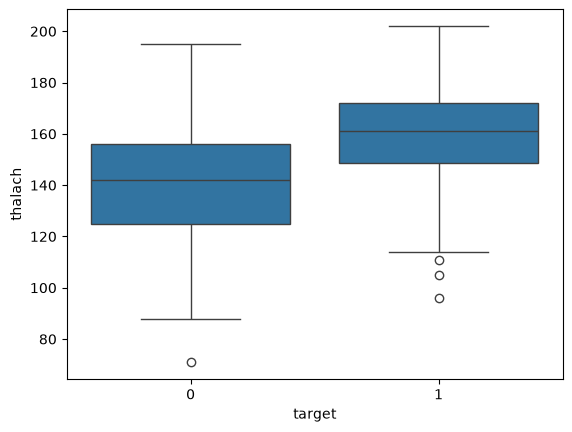

In [6]:
# (a) Tỉ lệ mắc bệnh theo loại đau ngực cp?
df.groupby('cp')['target'].mean()

# (b) thalach (nhịp tim tối đa) có khác nhau giữa 2 nhóm target không?
import seaborn as sns
sns.boxplot(data=df, x='target', y='thalach')

# (c) Tỉ lệ mắc bệnh theo nhóm tuổi?
df['age_group'] = pd.cut(df['age'], bins=[0,40,50,60,100], labels=['<40','40-50','50-60','60+'])
df.groupby('age_group', observed=True)['target'].mean()

xây pipeline tiền xử lý
xác định đúng loại biến


In [7]:
#viết pipeline

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

NUMERIC = ['age','trestbps','chol','thalach','oldpeak']
CATEGORICAL = ['cp','restecg','slope','ca','thal']
BINARY = ['sex','fbs','exang']

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), NUMERIC),
    ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), CATEGORICAL),
    ('bin', 'passthrough', BINARY),
])

In [8]:
#chia train/test
from sklearn.model_selection import train_test_split

X = df.drop(columns=['target', 'age_group'])   # nhớ bỏ cột phụ age_group đã tạo ở EDA
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(y_train.mean(), y_test.mean())   # phải gần bằng nhau

0.5435684647302904 0.5409836065573771


In [9]:
#baseline
from sklearn.dummy import DummyClassifier

dummy = DummyClassifier(strategy='most_frequent')
dummy.fit(X_train, y_train)
print(dummy.score(X_test, y_test))

0.5409836065573771


In [10]:
#train logistic regression với CV chọn C
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegressionCV
from sklearn.model_selection import StratifiedKFold

def train_logreg(penalty):
    solver = 'liblinear' if penalty == 'l1' else 'lbfgs'
    model = LogisticRegressionCV(
        Cs=10, cv=StratifiedKFold(5, shuffle=True, random_state=42),
        penalty=penalty, solver=solver,
        scoring='roc_auc',      # xem cảnh báo bên dưới
        max_iter=5000, random_state=42,
    )
    pipe = Pipeline([('prep', preprocessor), ('clf', model)])
    pipe.fit(X_train, y_train)
    return pipe

pipe_l2 = train_logreg('l2')

d:\WORK\Cat Linh_Lab_MachineLearning\01-Hoc-May\01-Phan-Loai\TT-04-Logistic-Regression\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:2092: FutureWarning: The default value for l1_ratios will change from None to (0.0,) in version 1.10. From version 1.10 onwards, only array-like with values in [0, 1] will be allowed, None will be forbidden. To avoid this warning, explicitly set a value, e.g. l1_ratios=(0,).
  warnings.warn(
d:\WORK\Cat Linh_Lab_MachineLearning\01-Hoc-May\01-Phan-Loai\TT-04-Logistic-Regression\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:2123: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratios' and 'Cs' instead. Use l1_ratios=(0,) instead of penalty='l2', l1_ratios=(1,) instead of penalty='l1', l1_ratios set to floats between 0 and 1 instead of penalty='elasticnet', and Cs=(np.inf,) instead of penalty=None.
  warnings.warn(
d:\WORK\Cat

In [11]:
#in bảng odd ratio
import numpy as np

clf = pipe_l2.named_steps['clf']
feature_names = (NUMERIC 
    + list(preprocessor.named_transformers_['cat'].get_feature_names_out(CATEGORICAL))
    + BINARY)

odds_table = pd.DataFrame({
    'dac_trung': feature_names,
    'he_so_w': clf.coef_[0],
    'odds_ratio': np.exp(clf.coef_[0]),
}).sort_values('odds_ratio', ascending=False)

print(odds_table)

    dac_trung   he_so_w  odds_ratio
7        cp_3  2.082656    8.025754
6        cp_2  1.859927    6.423265
16     thal_1  0.925737    2.523729
3     thalach  0.919368    2.507705
5        cp_1  0.763750    2.146311
15       ca_4  0.747560    2.111841
11    slope_2  0.532062    1.702439
17     thal_2  0.478009    1.612860
8   restecg_1  0.362045    1.436263
0         age  0.323295    1.381673
20        fbs  0.225824    1.253355
9   restecg_2 -0.179704    0.835517
2        chol -0.264455    0.767624
4     oldpeak -0.320357    0.725890
1    trestbps -0.380947    0.683214
10    slope_1 -0.538038    0.583893
18     thal_3 -0.744839    0.474811
21      exang -0.944838    0.388742
14       ca_3 -1.442656    0.236299
19        sex -1.811561    0.163399
12       ca_1 -1.962312    0.140533
13       ca_2 -2.984626    0.050558


In [12]:
# Train Logistic Regression với L1
pipe_l1 = train_logreg('l1')

# Lấy hệ số
coefs_l1 = pipe_l1.named_steps['clf'].coef_[0]

# Đếm số hệ số gần bằng 0
n_zero = np.isclose(coefs_l1, 0).sum()

print("Số hệ số = 0:", n_zero)
print("Tổng số hệ số:", len(coefs_l1))

d:\WORK\Cat Linh_Lab_MachineLearning\01-Hoc-May\01-Phan-Loai\TT-04-Logistic-Regression\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:2092: FutureWarning: The default value for l1_ratios will change from None to (0.0,) in version 1.10. From version 1.10 onwards, only array-like with values in [0, 1] will be allowed, None will be forbidden. To avoid this warning, explicitly set a value, e.g. l1_ratios=(0,).
  warnings.warn(
d:\WORK\Cat Linh_Lab_MachineLearning\01-Hoc-May\01-Phan-Loai\TT-04-Logistic-Regression\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:2123: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratios' and 'Cs' instead. Use l1_ratios=(0,) instead of penalty='l2', l1_ratios=(1,) instead of penalty='l1', l1_ratios set to floats between 0 and 1 instead of penalty='elasticnet', and Cs=(np.inf,) instead of penalty=None.
  warnings.warn(
d:\WORK\Cat

Số hệ số = 0: 2
Tổng số hệ số: 22


In [13]:
from sklearn.metrics import (
    roc_auc_score,
    recall_score,
    precision_score,
    accuracy_score
)

def evaluate_model(model, X_test, y_test):
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    return {
        "Accuracy": accuracy_score(y_test, y_pred),
        "AUC": roc_auc_score(y_test, y_prob),
        "Recall": recall_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred)
    }

result_l2 = evaluate_model(pipe_l2, X_test, y_test)
result_l1 = evaluate_model(pipe_l1, X_test, y_test)

print("L2:", result_l2)
print("L1:", result_l1)

L2: {'Accuracy': 0.819672131147541, 'AUC': 0.9036796536796537, 'Recall': 0.8484848484848485, 'Precision': 0.8235294117647058}
L1: {'Accuracy': 0.8360655737704918, 'AUC': 0.9004329004329005, 'Recall': 0.8484848484848485, 'Precision': 0.8484848484848485}


In [14]:
comparison = pd.DataFrame(
    [result_l2, result_l1],
    index=["L2", "L1"]
)

comparison

,Accuracy,AUC,Recall,Precision
L2,0.819672,0.903680,0.848485,0.823529
L1,0.836066,0.900433,0.848485,0.848485


In [15]:
#so sánh với baseline
baseline_accuracy = dummy.score(X_test, y_test)

print("Baseline accuracy:", baseline_accuracy)
print("L2 accuracy:", result_l2["Accuracy"])
print("L1 accuracy:", result_l1["Accuracy"])

Baseline accuracy: 0.5409836065573771
L2 accuracy: 0.819672131147541
L1 accuracy: 0.8360655737704918


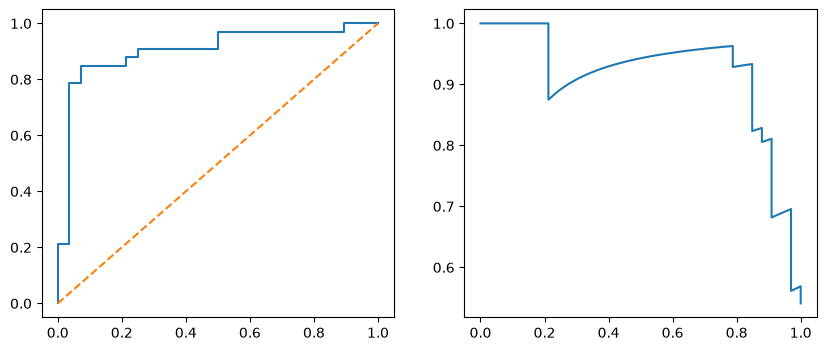

In [16]:
#vẽ ROC và precision recall
from sklearn.metrics import roc_curve, precision_recall_curve, roc_auc_score
import matplotlib.pyplot as plt

y_proba = pipe_l2.predict_proba(X_test)[:,1]
fpr, tpr, _ = roc_curve(y_test, y_proba)
precision, recall, thresholds = precision_recall_curve(y_test, y_proba)

fig, ax = plt.subplots(1,2, figsize=(10,4))
ax[0].plot(fpr, tpr); ax[0].plot([0,1],[0,1],'--')
ax[1].plot(recall, precision)
plt.show()

In [17]:
#kiểm định và so sánh
from statsmodels.stats.outliers_influence import variance_inflation_factor

X_trans = preprocessor.transform(X_train)
X_vif = pd.DataFrame(X_trans, columns=feature_names)
X_vif.insert(0, 'const', 1.0)

vif = pd.DataFrame({
    'bien': X_vif.columns[1:],
    'VIF': [variance_inflation_factor(X_vif.values, i) for i in range(1, X_vif.shape[1])]
}).sort_values('VIF', ascending=False)
print(vif)

         bien        VIF
17     thal_2  31.736901
18     thal_3  31.198034
16     thal_1   7.401774
11    slope_2   6.441644
10    slope_1   5.503435
4     oldpeak   1.988433
3     thalach   1.747057
6        cp_2   1.683640
0         age   1.544826
21      exang   1.543679
5        cp_1   1.530471
19        sex   1.422434
13       ca_2   1.389175
14       ca_3   1.323544
7        cp_3   1.293173
12       ca_1   1.273863
1    trestbps   1.213297
2        chol   1.161804
8   restecg_1   1.160283
20        fbs   1.127129
9   restecg_2   1.106985
15       ca_4   1.056868


In [18]:
#so sánh với SVM và RF
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score

for name, clf in [
    ('SVM', SVC(kernel='rbf', probability=True, random_state=42)),
    ('RandomForest', RandomForestClassifier(n_estimators=300, max_depth=5, random_state=42)),
]:
    p = Pipeline([('prep', preprocessor), ('clf', clf)])
    scores = cross_val_score(p, X_train, y_train, cv=5, scoring='roc_auc')
    print(name, scores.mean(), scores.std())

d:\WORK\Cat Linh_Lab_MachineLearning\01-Hoc-May\01-Phan-Loai\TT-04-Logistic-Regression\venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
d:\WORK\Cat Linh_Lab_MachineLearning\01-Hoc-May\01-Phan-Loai\TT-04-Logistic-Regression\venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
d:\WORK\Cat Linh_Lab_MachineLearning\01-Hoc-May\01-Phan-Loai\TT-04-Logistic-Regression\venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probabilit

SVM 0.8958689458689457 0.04125422517216252
RandomForest 0.8984200984200983 0.027976805878933923


In [19]:
#diễn giải 1 ca bệnh cụ thể
patient = X_test.iloc[[0]]     # tự chọn 1 bệnh nhân bất kỳ trong test
proba = pipe_l2.predict_proba(patient)[0,1]
print(f"Xác suất mắc bệnh: {proba:.1%}")

Xác suất mắc bệnh: 20.5%


In [20]:
#lưu model
import joblib
joblib.dump({
    'pipeline': pipe_l2,
    'feature_names': feature_names,
    'chosen_threshold': chosen_threshold,
}, '../models/logreg_pipeline.joblib')

NameError: name 'chosen_threshold' is not defined